In [3]:
print ('end')

end


In [5]:

import pandas as pd

# Set the seed

RAW_DATA_DIR = "../data/raw"
TEST_DATA_DIR = "../data/synthetic/test_data.pkl"
VALIDATION_DATA_DIR = "../data/synthetic/val_data.pkl"
TRAINING_DATA_DIR = "../data/synthetic/train_split.pkl"

# with open(TRAINING_DATA_DIR, 'rb') as f:
#     data = 
data = pd.read_pickle(VALIDATION_DATA_DIR)
print (data)
# print(mapping)

         id                                           waferMap  failureCode  \
0         0  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 255, ...            3   
1         1  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 128...            2   
2         2  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 255, 255, 255,...            8   
3         2  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...            8   
4         2  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...            8   
...     ...                                                ...          ...   
12445  5101  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...            4   
12446  5102  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...            8   
12447  5102  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...            3   
12448  5103  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 255, 255, 255,...            8   
12449  5103  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 128...            4   

      failureType                                  

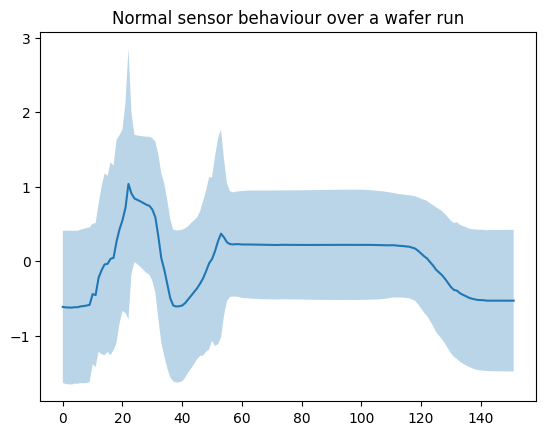

In [ ]:
import numpy as np
from sktime.datasets import load_from_tsfile
X, y = load_from_tsfile("../data/original_raw/Wafer_TRAIN.ts")
X_filtered = X.iloc[np.argwhere(y=='1').flatten()]
data_2d = np.array(X_filtered['dim_0'].tolist())

# per-timestep mean and std across all normal samples
timestep_mean = data_2d.mean(axis=0)  # shape: (n_timesteps,)
timestep_std = data_2d.std(axis=0)    # shape: (n_timesteps,)

import matplotlib.pyplot as plt
plt.plot(timestep_mean, label='mean')
plt.fill_between(range(len(timestep_mean)),
                 timestep_mean - timestep_std,
                 timestep_mean + timestep_std,
                 alpha=0.3, label='±1 std')
plt.title('Normal sensor behaviour over a wafer run')
plt.show()

In [7]:
steady_state = data_2d[:, 55:120]
ss_mean = steady_state.mean(axis=0)
ss_std = steady_state.std(axis=0)

noise_ratio = ss_std.mean() / (ss_mean.mean() + 1e-9)
print(f"Noise ratio in steady state: {noise_ratio:.4f}")


Noise ratio in steady state: 3.3743


In [18]:
gas_flow_normal    = np.random.normal(100, 2)    # ±2 sccm
temperature_normal = np.random.normal(350, 3)    # ±3°C  
pressure_normal    = np.random.normal(1.2, 0.02) # ±0.02 torr
x = 0

In [20]:
BASELINE = { "temp": [temperature_normal,x], "gas_flow": [gas_flow_normal,x+1], "pressure": [pressure_normal,x+2] }
for key,[start,end] in BASELINE.items():
    print (start, end)

351.9430656143021 0
99.72347139765763 1
1.2304605971281604 2


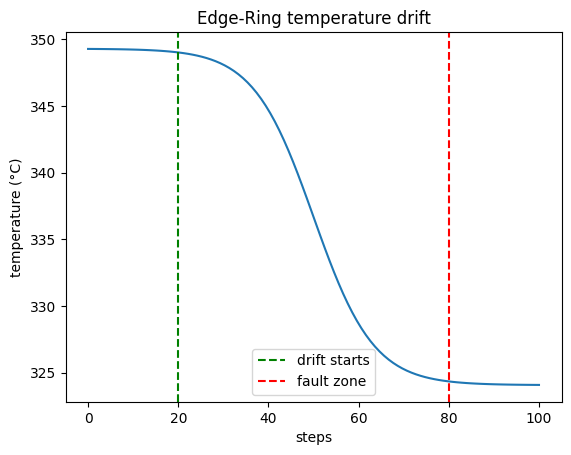

In [21]:
import matplotlib.pyplot as plt

t = np.linspace(0, 100, 100)
t_mid = 50
steepness = 0.15

# Test with temperature, Edge-Ring fault
start = np.random.normal(350, 3)
end = np.random.normal(325, 4)

drift = sigmoid_drift(t, start, end, t_mid, steepness)

plt.plot(t, drift)
plt.axvline(x=20, color='g', linestyle='--', label='drift starts')
plt.axvline(x=80, color='r', linestyle='--', label='fault zone')
plt.xlabel('steps')
plt.ylabel('temperature (°C)')
plt.title('Edge-Ring temperature drift')
plt.legend()
plt.show()

Displaying wafer map for defect type: none


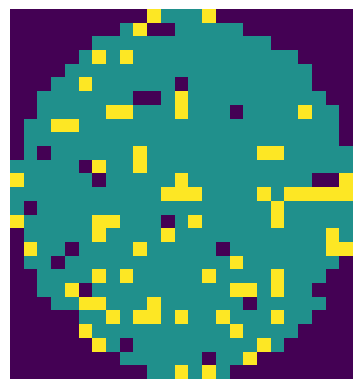

Displaying wafer map for defect type: Edge-Ring


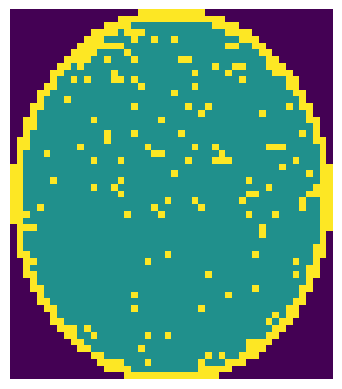

Displaying wafer map for defect type: Center


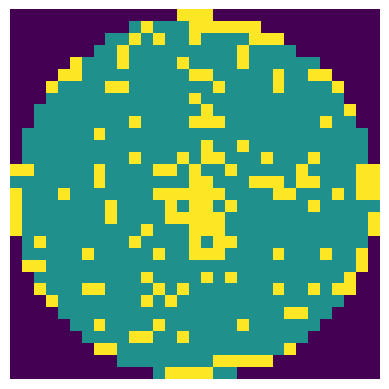

Displaying wafer map for defect type: Edge-Loc


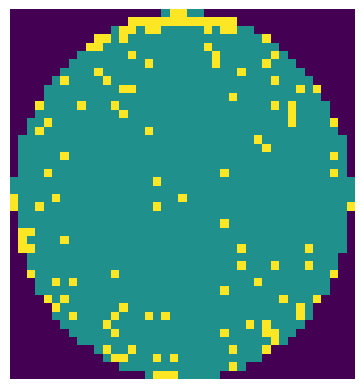

Displaying wafer map for defect type: Loc


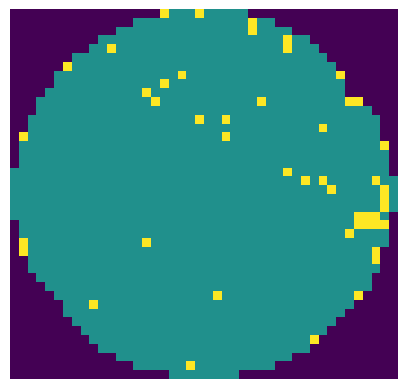

Displaying wafer map for defect type: Scratch


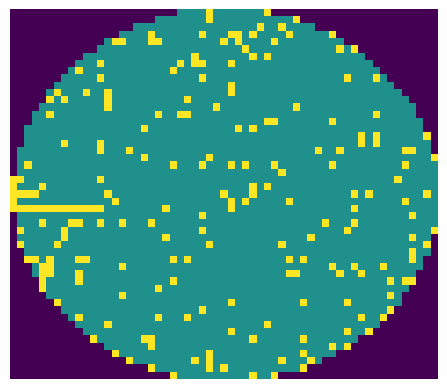

Displaying wafer map for defect type: Random


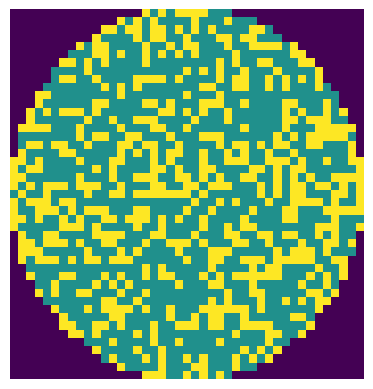

Displaying wafer map for defect type: Near-full


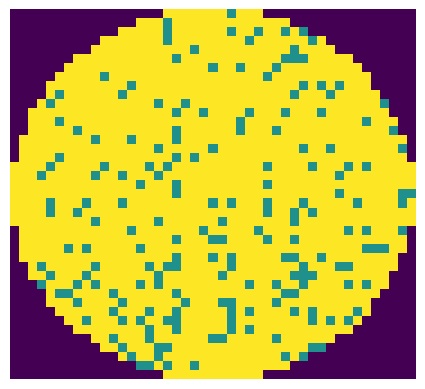

Displaying wafer map for defect type: Donut


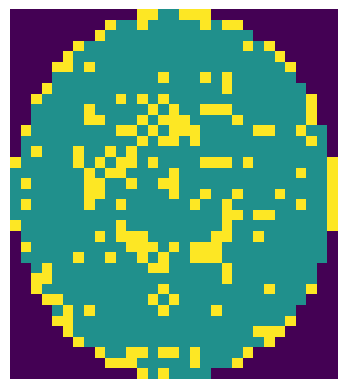

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create a random 2D array (grayscale) or 3D array (RGB)
for defect in data.failureType.unique():
    print (f"Displaying wafer map for defect type: {defect}")
    img = data[data.failureType == defect].iloc[0].waferMap  # Assuming waferMap is a 2D array

    plt.imshow(img,cmap='gray') # Use 'gray' for 2D arrays
    plt.axis('off')               # Hide axis ticks
    plt.show()